## 2026_Summer_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

(32, 32, 3)


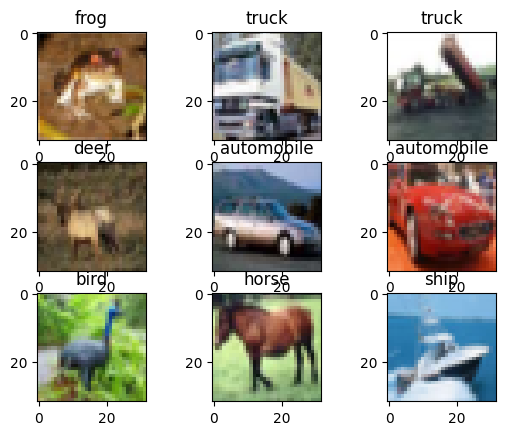

In [ ]:
# 데이터셋 정의 -> cifar-10
train_data = datasets.cifar.CIFAR10(
    './data/',
    train=True,
    download=True,
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

'''
다음과 같이 정의하여 함수형태로 후처리도 가능합니다

transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = data_transform(train_data)
'''


test_data = datasets.cifar.CIFAR10(
    root="../data/",
    train=False,
    download=True,
    transform=transforms.ToTensor())

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i])
    plt.title(train_data.classes[train_data.targets[i]])

print(train_data.data[0].shape)
plt.show()

In [ ]:
from torch.utils.data import Dataset

class CustomCIFAR10(Dataset):
    def __init__(self, root, train=True, download=False):
        # self.base_dataset = dataset.load_dataset(path = '')
        self.base_dataset = datasets.cifar.CIFAR10(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx]  # numpy array (H, W, C)
        label = self.base_dataset.targets[idx]

        if self.train:
            image = self.transform(image)

        return image, label

# 인스턴스 생성
train_data = CustomCIFAR10(root='./data/', train=True, download=True)
test_data = CustomCIFAR10(root='./data/', train=False, download=True)

## Modeling

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

        # return self.model(x)

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()

        # CNN 블럭 정의
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1) # 2차원의 feature map을 1차원으로

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [ ]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cuda


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=4096, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256,

In [ ]:
# Learning rate
lr = 1e-3

# Optimizer
optim = Adam(model.parameters(), lr=lr)

# Train loop
for epoch in range(100):
    for data, label in tqdm(train_loader): # read data
        optim.zero_grad() # Iniitlaization

        preds = model(data.to(device)) # prediction

        # Loss Function
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    if epoch==0 or epoch%10==9: # 10번마다 손실 출력
        print(f"epoch{epoch+1} loss:{loss.item()}")

# 모델 저장
torch.save(model.state_dict(), "CIFAR.pth")

100%|██████████| 782/782 [00:23<00:00, 32.65it/s]


epoch1 loss:1.6459541320800781


100%|██████████| 782/782 [00:23<00:00, 33.27it/s]


epoch10 loss:0.7928268909454346


100%|██████████| 782/782 [00:23<00:00, 32.85it/s]


...

epoch80 loss:0.40285295248031616


100%|██████████| 782/782 [00:23<00:00, 33.66it/s]


epoch90 loss:0.3248620629310608


100%|██████████| 782/782 [00:23<00:00, 33.56it/s]


epoch100 loss:0.09326416254043579


In [ ]:
model.load_state_dict(torch.load("CIFAR.pth", map_location=device))

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:04<00:00, 36.56it/s]

Accuracy:0.84


## 실습 1. MNIST 데이터 실습

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import Dataset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

### 데이터셋 정의

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.07MB/s]


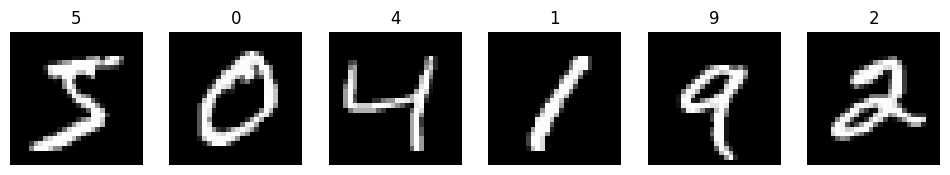

In [2]:
class CustomMNIST(Dataset):
    def __init__(self, root, train=True, download=True):
        self.base_dataset = datasets.MNIST(
            root=root,
            train=train,
            download=download
        )
        self.train = train

        # CIFAR-10 baseline과 동일한 방식(augmentation + normalize), 채널 수만 1개로 조정
        self.transform = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.RandomHorizontalFlip(0.0),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))  # 1채널이라 튜플 길이도 1
        ])

        self.test_transform = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]  # PIL Image, int
        if self.train:
            image = self.transform(image)
        else:
            image = self.test_transform(image)
        return image, label


train_data = CustomMNIST(root='./data/', train=True, download=True)
test_data = CustomMNIST(root='./data/', train=False, download=True)

# 샘플 확인
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    img, label = train_data.base_dataset[i]
    ax.imshow(img, cmap='gray')
    ax.set_title(label)
    ax.axis('off')
plt.show()

### Modeling

In [3]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

In [4]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        # 변경점: MNIST는 1채널이므로 block1의 in_channels만 3 -> 1
        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)  # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [5]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device 정보: {device}")

model = CNN(num_classes=10)
model.to(device)

device 정보: cuda


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=4096, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256,

### 학습

In [6]:
lr = 1e-3
optim = Adam(model.parameters(), lr=lr)

num_epochs = 15

for epoch in range(num_epochs):
    for data, label in tqdm(train_loader):
        optim.zero_grad()
        preds = model(data.to(device))
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    print(f"epoch{epoch+1} loss:{loss.item()}")

torch.save(model.state_dict(), "MNIST.pth")

100%|██████████| 938/938 [00:38<00:00, 24.33it/s]


epoch1 loss:0.08543078601360321


100%|██████████| 938/938 [00:35<00:00, 26.26it/s]


epoch2 loss:0.0019581825472414494


100%|██████████| 938/938 [00:35<00:00, 26.59it/s]


...

epoch13 loss:0.002250628313049674


100%|██████████| 938/938 [00:35<00:00, 26.54it/s]


epoch14 loss:0.001991542987525463


100%|██████████| 938/938 [00:36<00:00, 26.01it/s]


epoch15 loss:0.013284560292959213


### 평가

In [7]:
model.load_state_dict(torch.load("MNIST.pth", map_location=device))

num_corr = 0
with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:04<00:00, 35.28it/s]

Accuracy:0.99


## 실습 2. Batch normalization 추가

Modeling

In [8]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn1 = nn.BatchNorm2d(hidden_dim)   # BatchNorm2d 추가
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)   # conv -> bn -> relu 순서
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

In [9]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)  # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

학습

In [11]:
lr = 1e-3
optim = Adam(model.parameters(), lr=lr)

num_epochs = 15

for epoch in range(num_epochs):
    for data, label in tqdm(train_loader):
        optim.zero_grad()
        preds = model(data.to(device))
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    print(f"epoch{epoch+1} loss:{loss.item()}")

torch.save(model.state_dict(), "MNIST.pth")

100%|██████████| 938/938 [00:38<00:00, 24.43it/s]


epoch1 loss:0.022447338327765465


100%|██████████| 938/938 [00:37<00:00, 24.85it/s]


epoch2 loss:0.00511600635945797


100%|██████████| 938/938 [00:36<00:00, 25.94it/s]


...

epoch13 loss:0.0033750454895198345


100%|██████████| 938/938 [00:38<00:00, 24.25it/s]


epoch14 loss:0.011784453876316547


100%|██████████| 938/938 [00:38<00:00, 24.43it/s]


epoch15 loss:0.00031253285123966634


평가

In [13]:
model.load_state_dict(torch.load("MNIST.pth", map_location=device))
model.eval()

num_corr = 0
with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:03<00:00, 42.51it/s]

Accuracy:0.9931


## 실습 3. Dropout 추가

Modeling

In [14]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()


        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)
        self.dropout = nn.Dropout(p=0.5)    # Dropout 추가

        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)  # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)   # fc -> relu -> dropout 순서
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [15]:
model = CNN(num_classes=10)
model.to(device)

CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(12

학습

In [16]:
lr = 1e-3
optim = Adam(model.parameters(), lr=lr)

num_epochs = 15

for epoch in range(num_epochs):
    for data, label in tqdm(train_loader):
        optim.zero_grad()
        preds = model(data.to(device))
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    print(f"epoch{epoch+1} loss:{loss.item()}")

torch.save(model.state_dict(), "MNIST.pth")

100%|██████████| 938/938 [00:36<00:00, 25.50it/s]


epoch1 loss:0.08430863171815872


100%|██████████| 938/938 [00:38<00:00, 24.16it/s]


epoch2 loss:0.04701586067676544


100%|██████████| 938/938 [00:38<00:00, 24.65it/s]


...

epoch13 loss:0.011545248329639435


100%|██████████| 938/938 [00:35<00:00, 26.24it/s]


epoch14 loss:0.001264254911802709


100%|██████████| 938/938 [00:35<00:00, 26.16it/s]


epoch15 loss:0.00046625389950349927


평가

In [17]:
model.load_state_dict(torch.load("MNIST.pth", map_location=device))
model.eval()

num_corr = 0
with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:04<00:00, 35.20it/s]

Accuracy:0.9945


## 실습 4. train/val split + Earlystopping

학습

In [18]:
from torch.utils.data import random_split

val_ratio = 0.1
val_size = int(len(train_data) * val_ratio)
train_size = len(train_data) - val_size

train_subset, val_subset = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [19]:
lr = 1e-3
optim = Adam(model.parameters(), lr=lr)

num_epochs = 15
patience = 3          # val loss가 연속으로 안 좋아지면 멈춤
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):
    # ---- 학습 ----
    model.train()
    for data, label in tqdm(train_loader):
        optim.zero_grad()
        preds = model(data.to(device))
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    # ---- 검증 ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, label in val_loader:
            preds = model(data.to(device))
            val_loss += nn.CrossEntropyLoss()(preds, label.to(device)).item()
    val_loss /= len(val_loader)

    print(f"epoch{epoch+1} train_loss:{loss.item():.4f} val_loss:{val_loss:.4f}")

    # ---- EarlyStopping 체크 ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "MNIST.pth")  # 가장 좋은 시점만 저장
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

100%|██████████| 844/844 [00:32<00:00, 26.19it/s]


epoch1 train_loss:0.0352 val_loss:0.0419


100%|██████████| 844/844 [00:32<00:00, 26.18it/s]


epoch2 train_loss:0.0005 val_loss:0.0170


100%|██████████| 844/844 [00:32<00:00, 25.93it/s]


epoch3 train_loss:0.0014 val_loss:0.0189


100%|██████████| 844/844 [00:32<00:00, 25.75it/s]


epoch4 train_loss:0.0852 val_loss:0.0219


100%|██████████| 844/844 [00:31<00:00, 26.44it/s]


epoch5 train_loss:0.0849 val_loss:0.0240
Early stopping at epoch 5


In [20]:
model.load_state_dict(torch.load("MNIST.pth", map_location=device))
model.eval()

num_corr = 0
with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:03<00:00, 39.47it/s]

Accuracy:0.9955


## 실습 5. 학습 곡선 시각화

In [21]:
lr = 1e-3
optim = Adam(model.parameters(), lr=lr)

num_epochs = 15
patience = 3
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---- 학습 ----
    model.train()
    epoch_train_loss = 0
    for data, label in tqdm(train_loader):
        optim.zero_grad()
        preds = model(data.to(device))
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)

    # ---- 검증 ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, label in val_loader:
            preds = model(data.to(device))
            val_loss += nn.CrossEntropyLoss()(preds, label.to(device)).item()
    val_loss /= len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss)

    print(f"epoch{epoch+1} train_loss:{epoch_train_loss:.4f} val_loss:{val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "MNIST.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

100%|██████████| 844/844 [00:42<00:00, 19.79it/s]


epoch1 train_loss:0.0299 val_loss:0.0284


100%|██████████| 844/844 [00:40<00:00, 21.05it/s]


epoch2 train_loss:0.0243 val_loss:0.0322


100%|██████████| 844/844 [00:40<00:00, 21.08it/s]


...

epoch5 train_loss:0.0209 val_loss:0.0304


100%|██████████| 844/844 [00:39<00:00, 21.28it/s]


epoch6 train_loss:0.0230 val_loss:0.0297


100%|██████████| 844/844 [00:39<00:00, 21.15it/s]


epoch7 train_loss:0.0200 val_loss:0.0229
Early stopping at epoch 7


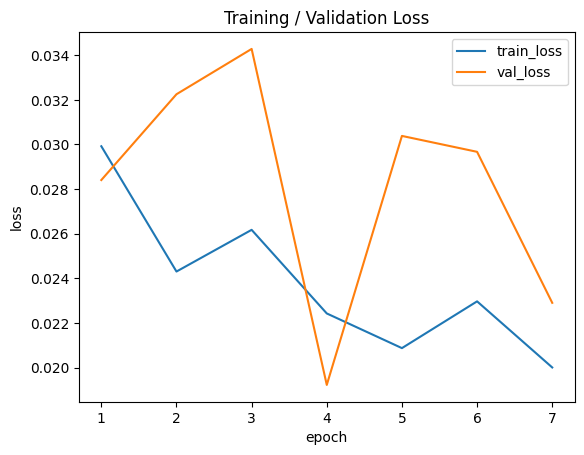

In [22]:
plt.plot(range(1, len(train_losses)+1), train_losses, label='train_loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.show()

In [23]:
model.load_state_dict(torch.load("MNIST.pth", map_location=device))
model.eval()

num_corr = 0
with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:04<00:00, 35.39it/s]

Accuracy:0.9949


## 결과

1. Baseline : Test Accuracy 99.00%
2. +BatchNorm2d : Test Accuracy 99.31%
3. +Dropout : Test Accuracy 99.45%
4. +train/val split + EarlyStopping : Test Accuracy 99.49%

- MNIST는 baseline만으로도 정확도 99%에 도달할 만큼 쉬운 문제라, 이후 기법 추가에 따른 절대적 정확도 상승폭은 크지 않음(99.00→99.55%). 다만 오류율 기준으로 보면 1.00%→0.45~0.51%로 절반 이상 감소했다는 점에서 상대적으로는 유의미한 개선으로 볼 수 있음
- 정규화 기법(BatchNorm, Dropout)과 EarlyStopping은 서로 다른 방식으로 일반화 성능에 기여함: BatchNorm은 학습 안정성/속도, Dropout은 과적합 방지, EarlyStopping은 불필요한 추가 학습으로 인한 성능 저하 방지